In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Define the column names
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

#  Load the dataset directly from a URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, names=column_names)

#  first 5 rows to make sure it worked
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# 1. Identify columns where a value of 0 is medically impossible
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. Replace the 0s with NaN (Not a Number) so Python knows it's missing data
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# 3. Fill those missing NaN values with the median of their respective columns
df.fillna(df.median(), inplace=True)

print("Zeroes fixed! Check the minimum values below to confirm:")
# df.describe() gives us a statistical summary of our data
df.describe()

Zeroes fixed! Check the minimum values below to confirm:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


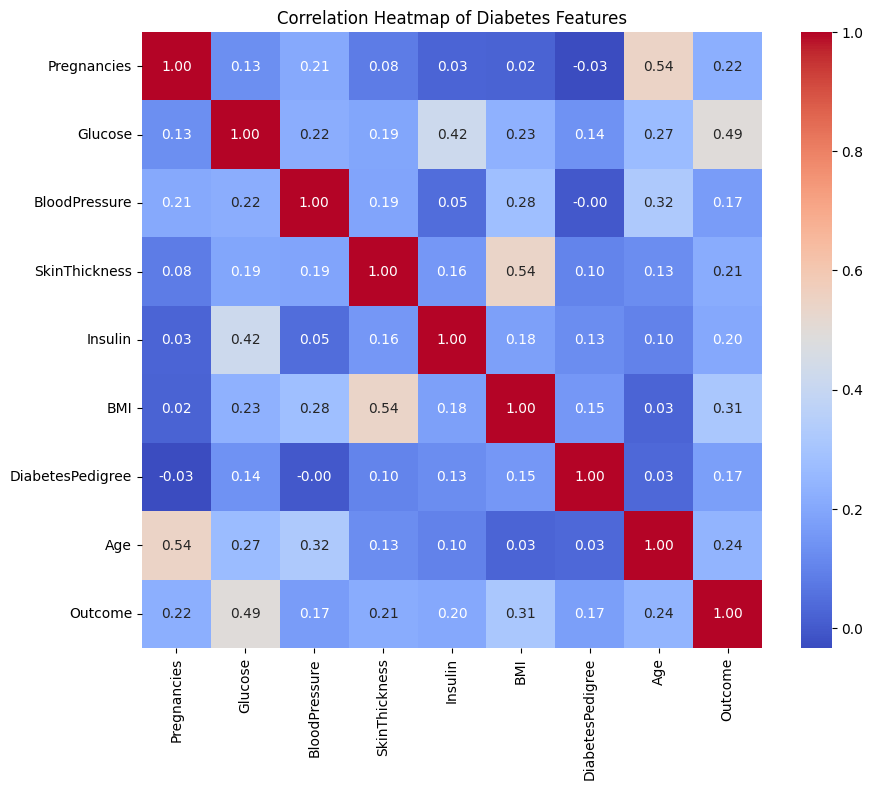

In [3]:
# Set the size of the graph
plt.figure(figsize=(10, 8))

# Create a heatmap of the correlations
# annot=True puts the numbers in the boxes, cmap sets the color theme
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap of Diabetes Features")
plt.show()

/tmp/ipykernel_21827/1974655356.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


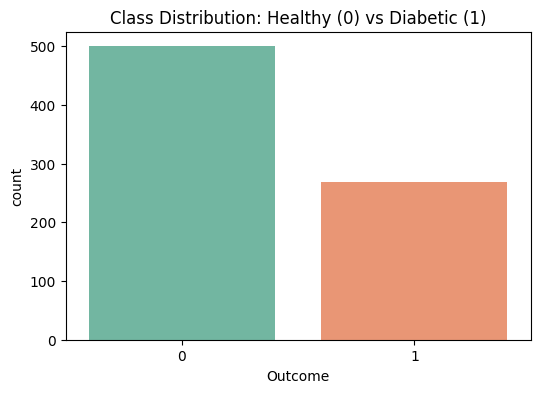

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title("Class Distribution: Healthy (0) vs Diabetic (1)")
plt.show()


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Separate Features (X) and Target (y)
X = df.drop('Outcome', axis=1) # Everything EXCEPT the outcome
y = df['Outcome']              # ONLY the outcome

# 2. Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features (Leveling the playing field)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Notice we don't "fit" the test data, no cheating!

# 4. Initialize the models
log_reg = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# 5. Train (fit) the models using our scaled training data
log_reg.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

print("Models trained ")

Models trained 


In [5]:
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

# 1. Ask the models to take the "final exam" (make predictions)
log_preds = log_reg.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test_scaled)

# 2. Score the Logistic Regression model
print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {accuracy_score(y_test, log_preds):.2f}")
print(f"Recall:   {recall_score(y_test, log_preds):.2f}")
print("\nClassification Report:\n", classification_report(y_test, log_preds))

# 3. Score the Random Forest model
print("\n=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.2f}")
print(f"Recall:   {recall_score(y_test, rf_preds):.2f}")
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

=== LOGISTIC REGRESSION ===
Accuracy: 0.75
Recall:   0.62

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154


=== RANDOM FOREST ===
Accuracy: 0.73
Recall:   0.64

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



In [6]:
# --- YOUR UPGRADED PIPELINE ---

# 1. The Stratified Split (Keeps the ratios perfectly balanced)
X_train_up, X_test_up, y_train_up, y_test_up = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Scale the data again
scaler_up = StandardScaler()
X_train_scaled_up = scaler_up.fit_transform(X_train_up)
X_test_scaled_up = scaler_up.transform(X_test_up)

# 3. The "Balanced" Random Forest (Forces it to care more about the diabetic patients)
# <--- Your idea added here!
rf_model_up = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model_up.fit(X_train_scaled_up, y_train_up)

# 4. Take the final exam again
rf_preds_up = rf_model_up.predict(X_test_scaled_up)

# 5. Print the new scores
print("=== UPGRADED RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test_up, rf_preds_up):.2f}")
print(f"Recall:   {recall_score(y_test_up, rf_preds_up):.2f}")
print("\nClassification Report:\n", classification_report(y_test_up, rf_preds_up))

=== UPGRADED RANDOM FOREST ===
Accuracy: 0.74
Recall:   0.57

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.81       100
           1       0.65      0.57      0.61        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.71       154
weighted avg       0.73      0.74      0.74       154



In [7]:
# 1. Get the raw probabilities instead of the final Yes/No predictions
# This returns an array where the second column is the % chance of having diabetes
probabilities = rf_model_up.predict_proba(X_test_scaled_up)[:, 1]

# 2. Set our custom medical threshold (e.g., 35% instead of 50%)
custom_threshold = 0.35

# 3. Create new predictions: If probability > 35%, predict 1, else 0
custom_preds = (probabilities >= custom_threshold).astype(int)

# 4. Score the new threshold
print(f"=== CUSTOM THRESHOLD (>{int(custom_threshold*100)}%) ===")
print(f"Accuracy: {accuracy_score(y_test_up, custom_preds):.2f}")
print(f"Recall:   {recall_score(y_test_up, custom_preds):.2f}")
print("\nClassification Report:\n", classification_report(y_test_up, custom_preds))


=== CUSTOM THRESHOLD (>35%) ===
Accuracy: 0.73
Recall:   0.72

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.74      0.78       100
           1       0.60      0.72      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



In [8]:
# 1. Initialize Logistic Regression with 'balanced' class weights
log_reg_up = LogisticRegression(random_state=42, class_weight='balanced')

# 2. Train the model using our upgraded, stratified data
log_reg_up.fit(X_train_scaled_up, y_train_up)

# 3. Get the raw probabilities instead of the default Yes/No
log_probabilities = log_reg_up.predict_proba(X_test_scaled_up)[:, 1]

# 4. Apply our custom 35% medical threshold
custom_threshold = 0.35
log_custom_preds = (log_probabilities >= custom_threshold).astype(int)

# 5. Print the new final scores
print(f"=== UPGRADED LOGISTIC REGRESSION (>{int(custom_threshold*100)}% THRESHOLD) ===")
print(f"Accuracy: {accuracy_score(y_test_up, log_custom_preds):.2f}")
print(f"Recall:   {recall_score(y_test_up, log_custom_preds):.2f}")
print("\nClassification Report:\n", classification_report(y_test_up, log_custom_preds))

=== UPGRADED LOGISTIC REGRESSION (>35% THRESHOLD) ===
Accuracy: 0.73
Recall:   0.89

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.64      0.75       100
           1       0.57      0.89      0.70        54

    accuracy                           0.73       154
   macro avg       0.74      0.76      0.72       154
weighted avg       0.79      0.73      0.73       154



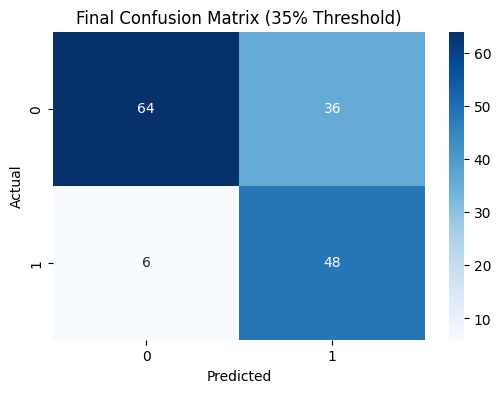

In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_up, log_custom_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix (35% Threshold)")
plt.show()

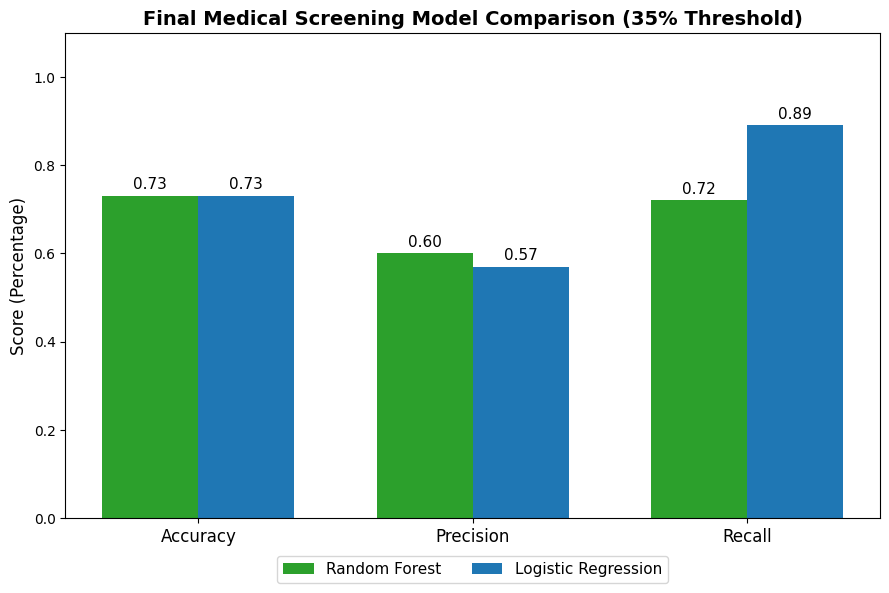

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define our final models and their scores
labels = ['Accuracy', 'Precision', 'Recall']

# Scores from our 35% Threshold tests
rf_scores = [0.73, 0.60, 0.72]   # Upgraded Random Forest
log_scores = [0.73, 0.57, 0.89]  # Upgraded Logistic Regression

x = np.arange(len(labels))  # The label locations
width = 0.35                # The width of the bars

# 2. Set up the graph size and style
fig, ax = plt.subplots(figsize=(9, 6))

# 3. Create the bars
rects1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest', color='#2ca02c')
rects2 = ax.bar(x + width/2, log_scores, width, label='Logistic Regression', color='#1f77b4')

# 4. Add labels, title, and formatting
ax.set_ylabel('Score (Percentage)', fontsize=12)
ax.set_title('Final Medical Screening Model Comparison (35% Threshold)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.1) # Set the Y-axis limit slightly above 1.0 for visual padding

# Move the legend out of the way of the bars
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=11)

# 5. Add the exact numbers on top of the bars for easy reading
ax.bar_label(rects1, padding=3, fontsize=11, fmt='%.2f')
ax.bar_label(rects2, padding=3, fontsize=11, fmt='%.2f')

# 6. Display the graph
plt.tight_layout()
plt.show()

In [31]:
import pandas as pd

# 1. Input the new patient's medical data
# (Try changing these numbers to see how the prediction changes!)
new_patient_data = {
     'Pregnancies': [1],
    'Glucose': [92],
    'BloodPressure': [72],
    'SkinThickness': [20],
    'Insulin': [85],
    'BMI': [22.4],
    'DiabetesPedigree': [0.18],
    'Age': [24]
}
# 2. Convert the data into a Pandas DataFrame
new_patient_df = pd.DataFrame(new_patient_data)

# 3. CRITICAL STEP: Scale the new patient's data!
# We MUST use the exact same 'scaler_up' we used on the training data.
# Notice we use .transform() NOT .fit_transform(). We don't want to change the scaler!
new_patient_scaled = scaler_up.transform(new_patient_df)

# 4. Get the raw probability from our winning doctor (log_reg_up)
patient_probability = log_reg_up.predict_proba(new_patient_scaled)[0, 1]

# 5. Apply our custom 35% screening threshold
threshold = 0.35
diagnosis = "DIABETES DETECTED (Requires Follow-up)" if patient_probability >= threshold else "HEALTHY (No Diabetes Detected)"

# 6. Print the  final medical report
print("========================================")
print("      PRELIMINARY DIAGNOSTIC REPORT     ")
print("========================================")
print(f"Model Probability: {patient_probability * 100:.2f}%")
print(f"Screening Threshold: {threshold * 100:.0f}%")
print("----------------------------------------")
print(f"FINAL RESULT: {diagnosis}")
print("========================================")

      PRELIMINARY DIAGNOSTIC REPORT     
Model Probability: 3.98%
Screening Threshold: 35%
----------------------------------------
FINAL RESULT: HEALTHY (No Diabetes Detected)
